# Rossmann Store Sales: Results and Discussion

reads what the modeling notebook saved and does the comparisons, wilcoxon test, complexity vs performance and error analysis.

modeling notebook has to run first for the trainings

## Load the saved results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from pathlib import Path
from scipy.stats import wilcoxon

In [2]:
RES = Path.cwd().parent/"results"
metrics = pd.read_csv(RES/"metrics.csv") # csv's that the modeling notebook has saved
preds = pd.read_csv(RES/"predictions_test.csv", parse_dates=['Date'])
imp = pd.read_csv(RES/"lgbm_importance.csv", index_col= 0)["importance"]
runtimes = pd.read_csv(RES/"runtimes.csv")
print("test preds", preds.shape)
metrics

test preds (30188, 9)


,model,features,split,RMSE,MAE,RMSPE
0,Seasonal Naive,lag7,val,3751.0,2756.5,0.476
1,Seasonal Naive,lag7,test,2595.9,2048.0,0.384
2,Ridge,basic,val,2801.0,1989.5,0.437
3,Ridge,basic,test,2575.6,1892.5,0.449
4,Ridge,engineered,val,1390.7,982.5,0.193
5,Ridge,engineered,test,1095.9,813.4,0.190
6,LightGBM,basic,val,1696.3,1153.6,0.243
7,LightGBM,basic,test,1559.9,1088.3,0.240
8,LightGBM,engineered,val,917.1,633.8,0.126
9,LightGBM,engineered,test,846.9,598.9,0.124


## Model comparison

Comparing best version of each model

In [3]:
# picking main feature set for each model
main = {"Seasonal Naive" : 'lag7', "Ridge" : "engineered", "LightGBM" : "engineered","TFT" : "deep"}
rows=[]
col=[]

In [4]:
for mdl, feat in main.items():
    for split in ["val","test"]:
        r = metrics[(metrics.model==mdl) & (metrics.features==feat) & (metrics.split==split)].iloc[0]
        rows.append((mdl, split, r.RMSE,r.MAE,r.RMSPE))
comp = pd.DataFrame(rows, columns=["model","split","RMSE","MAE","RMSPE"])
test = comp[comp.split=="test"].set_index('model')[["RMSE","MAE","RMSPE"]].sort_values('RMSE')
test

,RMSE,MAE,RMSPE
model,,,
LightGBM,846.9,598.9,0.124
TFT,877.9,616.2,0.127
Ridge,1095.9,813.4,0.190
Seasonal Naive,2595.9,2048.0,0.384


In [5]:
#Same models on june validation
comp[comp.split=="val"].set_index('model')[["RMSE","MAE","RMSPE"]].sort_values('RMSE')

,RMSE,MAE,RMSPE
model,,,
TFT,837.2,569.6,0.115
LightGBM,917.1,633.8,0.126
Ridge,1390.7,982.5,0.193
Seasonal Naive,3751.0,2756.5,0.476


In [6]:
base = test.loc["Seasonal Naive","RMSE"]
improve = test[["RMSE"]].copy()
improve["Improvement Over Baseline (%)"] = (((base-improve.RMSE)/base) *100).round(1)
#improve["Improvement Over Baseline (%)"] = (((base-improve.RMSE)/base) *100)
improve

,RMSE,Improvement Over Baseline (%)
model,,
LightGBM,846.9,67.4
TFT,877.9,66.2
Ridge,1095.9,57.8
Seasonal Naive,2595.9,0.0


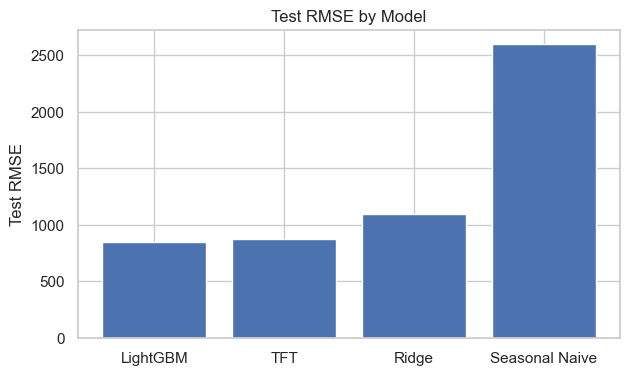

In [7]:
plt.figure(figsize=(7,4))
plt.bar(test.index, test["RMSE"])
plt.title("Test RMSE by Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=0)
plt.show()

## Statistical comparison (wilcoxon signed rank)

to make sure the gaps between the models are real

In [8]:
cols = ["naive","ridge","lgbm","tft"]

In [9]:
# abs error for each model
lgbm_err = (preds["Sales"] - preds["lgbm"]).abs()
ridge_err = (preds["Sales"] - preds["ridge"]).abs()
tft_err=(preds["Sales"] - preds["tft"]).abs()

In [10]:
# lightgbm vs ridge
stat,p = wilcoxon(lgbm_err, ridge_err)

if lgbm_err.mean() <ridge_err.mean():
    better="lgbm"
else:
    better="ridge"

print("lgbm vs ridge", " abs err", round(lgbm_err.mean(),1), 'vs', round(ridge_err.mean(), 1), ' p',round(p,8), " better",better)

lgbm vs ridge  abs err 598.9 vs 813.4  p 0.0  better lgbm


In [11]:
# lightgbm vs tft
stat,p = wilcoxon(lgbm_err, tft_err)

if lgbm_err.mean() <tft_err.mean():
    better="lgbm"
else:
    better="tft"

print("lgbm vs tft", " abs err", round(lgbm_err.mean(),1), 'vs', round(tft_err.mean(), 1), ' p',round(p,8), " better",better)

lgbm vs tft  abs err 598.9 vs 616.2  p 9.2e-06  better lgbm


In [12]:
# tft vs ridge
stat,p = wilcoxon(tft_err, ridge_err)

if tft_err.mean() <ridge_err.mean():
    better="tft"
else:
    better="ridge"

print("tft vs ridge", " abs err", round(tft_err.mean(),1), 'vs', round(ridge_err.mean(), 1), ' p',round(p,8), " better",better)

tft vs ridge  abs err 616.2 vs 813.4  p 0.0  better tft


## Feature engineering impact

In [13]:
# test rmse for each feature set for ridge and lightgbm
fe = metrics[(metrics.split=='test') & (metrics.model.isin(["Ridge","LightGBM"]))]
fe.pivot(index='model',columns="features", values = "RMSE")

features,basic,eng+extra,engineered
model,,,
LightGBM,1559.9,849.6,846.9
Ridge,2575.6,NaN,1095.9


the improvement from basic to engineered was a lot for both

## What features lightgbm uses most

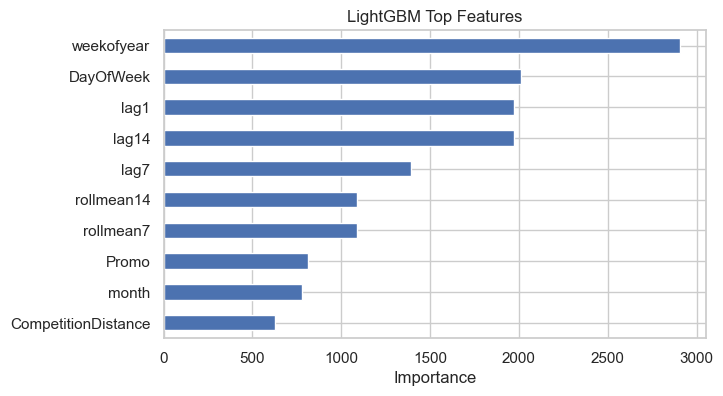

In [14]:
top = imp.sort_values(ascending=False).head(10)
plt.figure(figsize=(7,4))
top[::-1].plot(kind='barh')
plt.title("LightGBM Top Features")
plt.xlabel("Importance")
plt.show()

## Complexity vs Performance

In [15]:
cx = runtimes.merge(test.reset_index()[["model","RMSE"]], on='model')
cx

,model,train_seconds,complexity,RMSE
0,Seasonal Naive,0.0,"no training, just last weeks value",2595.9
1,Ridge,0.2,23 coefficients,1095.9
2,LightGBM,4.8,525 trees,846.9
3,TFT,1416.0,2344278 parameters,877.9


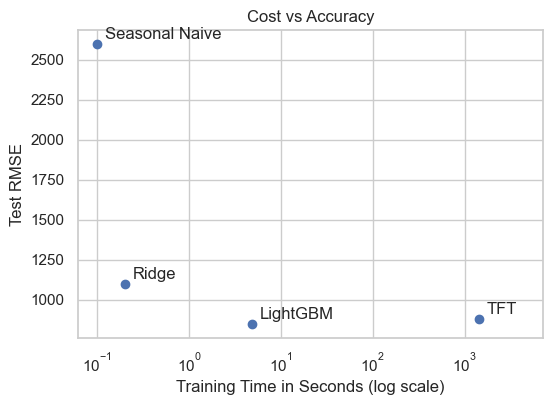

In [16]:
plt.figure(figsize=(6, 4))

cx["plot_seconds"] = cx["train_seconds"].clip(lower = 0.1)#clip for naive
plt.scatter(cx["plot_seconds"],cx["RMSE"])

for i,r in cx.iterrows():
    #plt.annotate(r["model"], (r["plot_seconds"],r["RMSE"]))
    plt.annotate(r["model"], (r["plot_seconds"],r["RMSE"]), xytext=(6,4), textcoords= 'offset points')

plt.xscale('log')
#plt.xlim(right = cx.train_seconds.max())
plt.xlim(right = cx.train_seconds.max()*5)
plt.xlabel("Training Time in Seconds (log scale)")
plt.ylabel("Test RMSE")
plt.title("Cost vs Accuracy")
plt.show()

tft costs minutes and many params but still doesn't beat lightgbm

## Error analysis

### by promo

In [17]:
def rmse(y,p):
    return(np.sqrt(np.mean((y-p) **2)))

In [18]:
# test rmse on promo vs non promo days for every model
rows=[]
for promo, g in preds.groupby("Promo"):
    if promo==1:
        label='promo'
    else:
        label="no promo"
    for c in cols:
        #rows.append((label,c, rmse(g.Sales,g[c]), 1))
        rows.append((label,c, round(rmse(g.Sales,g[c]), 1)))
by_promo = pd.DataFrame(rows, columns=["day","model","RMSE"]).pivot(index="model",columns="day", values="RMSE")
by_promo

day,no promo,promo
model,,
lgbm,739.2,950.2
naive,2593.1,2598.9
ridge,990.5,1199.9
tft,730.6,1013.9


### over the test month

In [19]:
#daily test rmse for every modle in july
recs=[]
for d,g in preds.groupby("Date"):
    row={"Date" : d}
    for c in cols:
        row[c]=rmse(g.Sales, g[c])
    recs.append(row)
daily = pd.DataFrame(recs).set_index("Date")

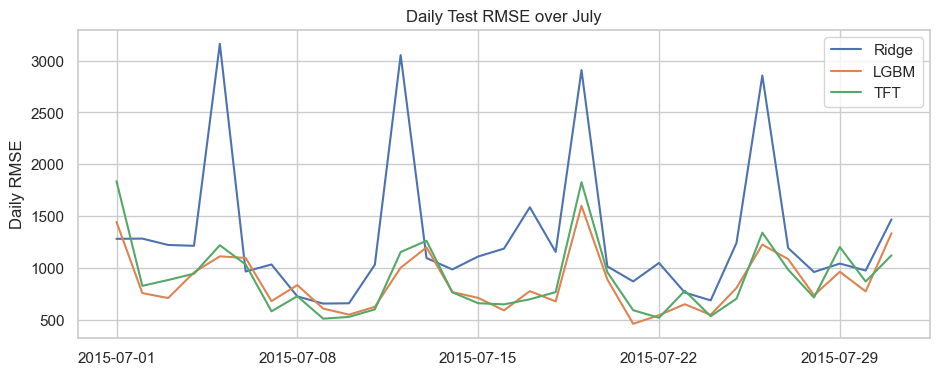

In [20]:
plt.figure(figsize=(11,4))
# not including naive on purpose to make the rest be clearer
plt.plot(daily.index,daily['ridge'], label="Ridge")
plt.plot(daily.index,daily['lgbm'], label="LGBM")
plt.plot(daily.index,daily['tft'], label="TFT")
plt.legend()
plt.ylabel("Daily RMSE")
plt.title("Daily Test RMSE over July")
plt.xticks(daily.index[::7])
plt.show() # error is higher on harder days like mondays (highest sales) and sundays that less stores are open

## Key findings

- Feature engineering helped the most.
- Lag and rolling features made Ridge and LightGBM much better than the basic features.
- LightGBM was the best model overal. The wilcoxon test also showed that its improvement was significant enough.
- Promo days were harder to handle for the trained models.
- TFT did a bit better than lightgbm on non promo days, but worse on promo days and overal.
- The daily plot showed that there are higher errors on harder days like mondays and sundays.